# Global Inflation (2020-2024): The Impact of Oil Prices, Supply Chain Pressures, and the Effectiveness of Gold as a Hedge
#### by Natthiya Veerakul
--------------

### 1) Introduction

This project explores the inflation surge between 2020 and 2024. The goal is to identify whether global supply chain pressures or oil prices were the primary drivers of global inflation, and if gold served as an effective inflation hedge. The dataset used is the Global Inflation Dynamics Post-COVID (2020–2024) from Kaggle.

https://www.kaggle.com/datasets/ssssws/global-inflation-dynamics-post-covid-20202024?resource=download

### How to Use This Notebook 
#### Necessary Python libraries
Ensure you have pandas, matplotlib, seaborn, and numpy installed in your Python environment.

#### API Use
This notebook connects to an external source for financial data. Ensure your API keys are stored in a .env file

#### Execution
Run all cells sfrom top to bottom to ensure data cleaning and transformations are applied before the visualizations are generated.

### 2) Data Setup

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Puifai\Desktop\Natthiya Veerakul\Project\inflation.csv")

df["date"] = pd.to_datetime(df["date"])

df["date"] = pd.to_datetime(df["date"], errors="coerce")

df = df.drop_duplicates()

df = df.dropna(subset=["date"])

print("Missing values:")
print(df.isnull().sum())

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

print("Global Inflation")
display(df.head())
print(df.info())
display(df.describe())

df.to_csv("inflation_cleaned.csv", index=False)

Missing values:
country               0
date                  0
inflation_rate        0
interest_rate         0
oil_price             0
gdp_growth            0
unemployment_rate     0
money_supply_m2       0
exchange_rate_usd     0
food_price_index      0
supply_chain_index    0
dtype: int64
Global Inflation


,country,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index
0,USA,2020-01-01,0.33,5.76,34.44,0.34,5.97,10558,69.95,94.29,3.66
1,USA,2020-02-01,4.12,4.33,44.75,0.02,5.80,6952,71.03,78.60,3.91
2,USA,2020-03-01,2.75,4.24,52.80,0.30,7.45,10244,71.00,102.91,3.70
3,USA,2020-04-01,4.36,4.52,39.19,2.28,5.23,9989,83.52,110.92,3.23
4,USA,2020-05-01,2.73,3.17,41.09,3.05,5.96,7982,70.10,86.53,3.94


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   country             100000 non-null  object        
 1   date                100000 non-null  datetime64[ns]
 2   inflation_rate      100000 non-null  float64       
 3   interest_rate       100000 non-null  float64       
 4   oil_price           100000 non-null  float64       
 5   gdp_growth          100000 non-null  float64       
 6   unemployment_rate   100000 non-null  float64       
 7   money_supply_m2     100000 non-null  int64         
 8   exchange_rate_usd   100000 non-null  float64       
 9   food_price_index    100000 non-null  float64       
 10  supply_chain_index  100000 non-null  float64       
dtypes: datetime64[ns](1), float64(8), int64(1), object(1)
memory usage: 8.4+ MB
None


,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-17 22:14:00.095999744,4.175859,2.559960,75.026843,2.476658,5.514667,11947.973270,46.908610,119.597836,1.939958
min,2020-01-01 00:00:00,-1.999003,-2.810000,22.640000,-4.580000,2.000000,3858.000000,2.340000,70.770000,1.000000
25%,2021-03-01 00:00:00,3.173408,1.190000,62.860000,1.090000,4.710000,10060.000000,22.610000,107.180000,1.240000
50%,2022-07-01 00:00:00,4.226506,2.590000,75.200000,2.520000,5.500000,11788.000000,42.360000,119.830000,1.670000
75%,2023-10-01 00:00:00,5.202572,3.940000,85.680000,3.940000,6.340000,13690.000000,73.310000,132.420000,2.270000
max,2024-12-01 00:00:00,9.634656,8.130000,153.770000,10.090000,9.140000,21241.000000,104.950000,165.300000,4.880000
std,NaN,1.463516,1.856475,24.380590,2.156974,1.199608,2744.008662,30.259072,17.118195,0.912450


### 3) Global Variables (Oil Price, Supply Chain)

#### 3.1) Global Inflation vs Oil Price

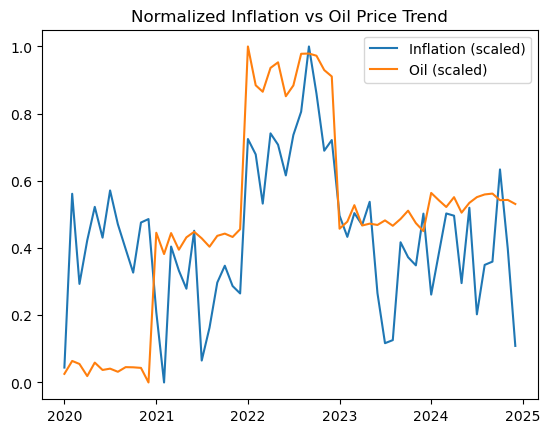

In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

temp = df.groupby("date")[["inflation_rate", "oil_price"]].mean().reset_index()

temp[["inflation_norm", "oil_norm"]] = scaler.fit_transform(
    temp[["inflation_rate", "oil_price"]]
)

plt.plot(temp["date"], temp["inflation_norm"], label="Inflation (scaled)")
plt.plot(temp["date"], temp["oil_norm"], label="Oil (scaled)")

plt.legend()
plt.title("Normalized Inflation vs Oil Price Trend")
plt.show()

#### 3.2) Global Inflation vs Supply Chain

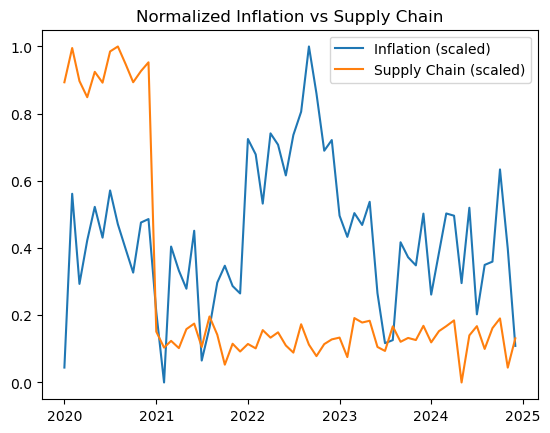

In [28]:
temp = df.groupby("date")[["inflation_rate", "supply_chain_index"]].mean().reset_index()

scaler = MinMaxScaler()

temp[["inflation_norm", "sc_norm"]] = scaler.fit_transform(
    temp[["inflation_rate", "supply_chain_index"]]
)

plt.plot(temp["date"], temp["inflation_norm"], label="Inflation (scaled)")
plt.plot(temp["date"], temp["sc_norm"], label="Supply Chain (scaled)")

plt.legend()
plt.title("Normalized Inflation vs Supply Chain")
plt.show()

#### 3.3) Correlation between Inflation, Oil Price, and Supply Chain

,inflation_rate,oil_price,supply_chain_index
inflation_rate,1.000000,0.520726,-0.023955
oil_price,0.520726,1.000000,-0.779438
supply_chain_index,-0.023955,-0.779438,1.000000


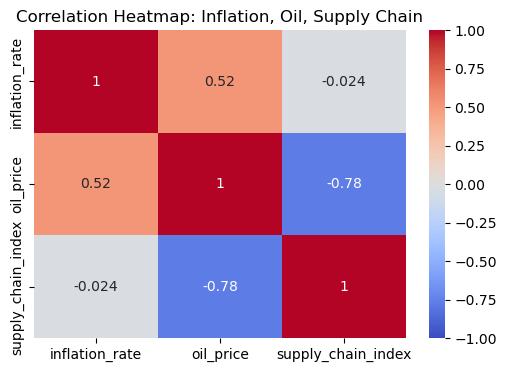

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

temp = df.groupby("date")[[
    "inflation_rate",
    "oil_price",
    "supply_chain_index"
]].mean()

corr = temp.corr()
display(corr)

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap: Inflation, Oil, Supply Chain")
plt.show()

From looking at the trend and heatmap, oil price and inflation rate moe together while it is opposite for supply chain and inflation rate, suggesting that oil price is a more direct driver than general supply chain pressures.

### 4) Recent Gold Price Data (from Market Stack)

In [5]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.environ.get("API_KEY")

if api_key:
    print(f"Key loaded: {api_key[:3]}...")
else:
    print("ERROR: API_KEY not found. Check your .env file.")

Key loaded: be3...


In [26]:
#a
import requests
import pandas as pd

url = "https://api.marketstack.com/v1/eod"
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

all_data = []

for ticker in tickers:
    params = {
        "access_key": api_key,
        "symbols": ticker,
        "date_from": "2024-01-01",
        "date_to": "2025-12-31",
        "limit": 1000
    }

    response = requests.get(url, params=params)
    data = response.json()

    if "data" in data:
        stock_df = pd.DataFrame(data["data"])
        stock_df["symbol"] = ticker
        all_data.append(stock_df)

final_df = pd.concat(all_data, ignore_index=True)

final_df.head()

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,664.75,665.00,659.44,660.09,7940400.0,665.0000,659.4400,660.09,664.75,7940359.0,1.0,0.0,META,ARCX,2025-12-31T00:00:00+0000
1,658.69,672.22,657.84,665.95,9177800.0,672.2200,657.8400,665.95,658.69,9187483.0,1.0,0.0,META,ARCX,2025-12-30T00:00:00+0000
2,658.01,660.25,654.39,658.69,8492300.0,660.2500,654.3900,658.69,658.01,8506477.0,1.0,0.0,META,ARCX,2025-12-29T00:00:00+0000
3,668.06,668.95,661.32,663.29,7062300.0,668.9499,661.3201,663.29,668.06,7133813.0,1.0,0.0,META,ARCX,2025-12-26T00:00:00+0000
4,662.53,668.18,662.20,667.55,5627500.0,668.1800,662.2000,667.55,662.53,5627512.0,1.0,0.0,META,ARCX,2025-12-24T00:00:00+0000


In [27]:
final_df["date"] = pd.to_datetime(final_df["date"])
final_df = final_df.sort_values("date")

gold_monthly = (
    final_df.set_index("date")["close"]
    .resample("MS")
    .mean()
    .reset_index()
    .rename(columns={"close": "gold_price"})
)

print("Gold monthly data:")
display(gold_monthly.head())
print(f"Shape: {gold_monthly.shape}")


Gold monthly data:


,date,gold_price
0,2025-05-01 00:00:00+00:00,480.535714
1,2025-06-01 00:00:00+00:00,506.370050
2,2025-07-01 00:00:00+00:00,514.536455
3,2025-08-01 00:00:00+00:00,524.325713
4,2025-09-01 00:00:00+00:00,538.026856


Shape: (8, 2)


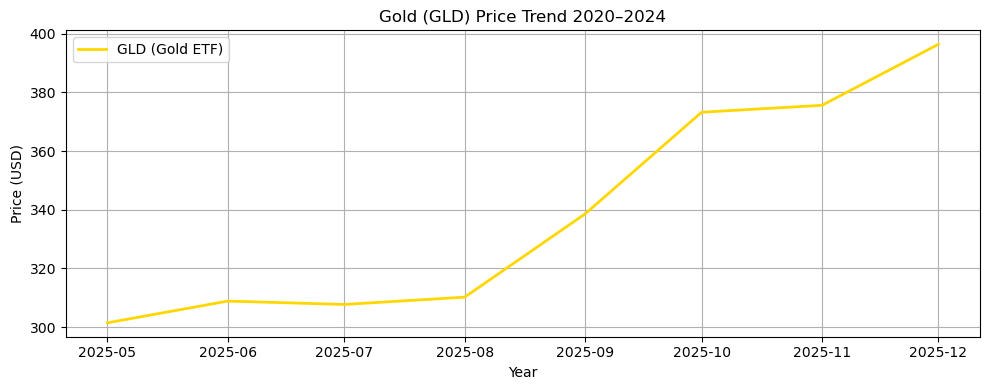

In [36]:
plt.figure(figsize=(10, 4))
plt.plot(gold_monthly["date"], gold_monthly["gold_price"], color="gold", linewidth=2, label="GLD (Gold ETF)")
plt.title("Gold (GLD) Price Trend 2020–2024")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5) Gold as Inflation Hedge

#### 5.1) Gold Price Trend 2024-2025
Since the Marketstack API only covers only one year, so GLD ETF closing prices sourced from Yahoo Finance are used to match the full 2020-2024 inflation dataset.

[*********************100%***********************]  1 of 1 completed


,date,gold_price
0,2020-01-01,149.330002
1,2020-02-01,148.380005
2,2020-03-01,148.050003
3,2020-04-01,158.800003
4,2020-05-01,162.910004


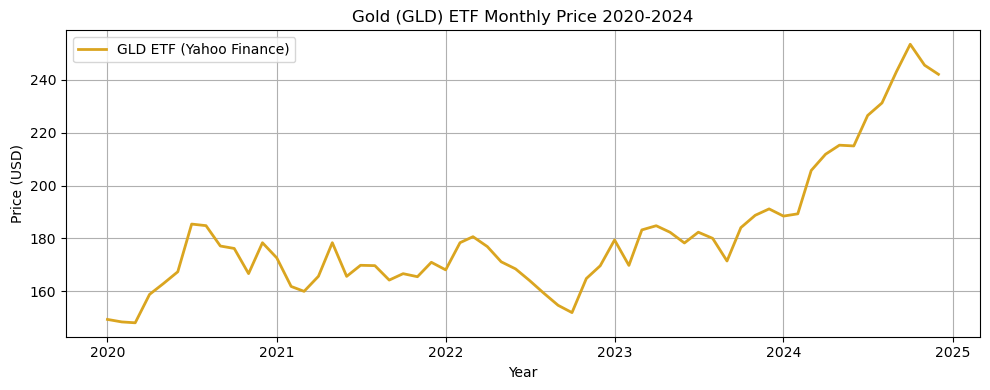

In [32]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

gld = yf.download(
    "GLD",
    start="2020-01-01",
    end="2025-01-01",
    interval="1mo"
)

gold_monthly = gld.reset_index()[["Date", "Close"]]

gold_monthly.columns = ["date", "gold_price"]

gold_monthly["date"] = pd.to_datetime(gold_monthly["date"]).dt.tz_localize(None)

display(gold_monthly.head())

plt.figure(figsize=(10, 4))

plt.plot(
    gold_monthly["date"],
    gold_monthly["gold_price"],
    color="goldenrod",
    linewidth=2,
    label="GLD ETF (Yahoo Finance)"
)

plt.title("Gold (GLD) ETF Monthly Price 2020-2024")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

#### 5.2) Global Inflation vs Gold Price

Merged rows: 60


,date,inflation_rate,ym,gold_price
0,2020-01-01,3.489042,2020-01,149.330002
1,2020-02-01,4.404037,2020-02,148.380005
2,2020-03-01,3.929493,2020-03,148.050003
3,2020-04-01,4.158877,2020-04,158.800003
4,2020-05-01,4.335114,2020-05,162.910004


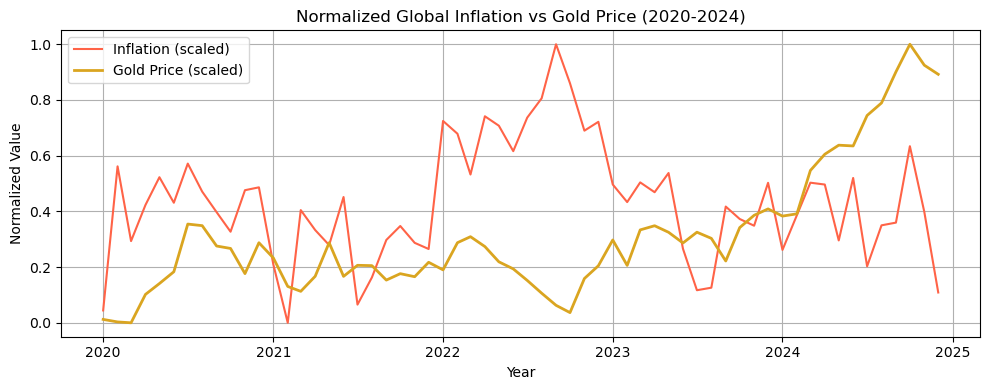

In [33]:
from sklearn.preprocessing import MinMaxScaler

global_inflation = (
    df.groupby("date")[["inflation_rate"]]
    .mean()
    .reset_index()
)

global_inflation["ym"] = global_inflation["date"].dt.to_period("M")
gold_monthly["ym"] = gold_monthly["date"].dt.to_period("M")

merged = pd.merge(global_inflation, gold_monthly[["ym", "gold_price"]], on="ym", how="inner")
print(f"Merged rows: {len(merged)}")
display(merged.head())

scaler = MinMaxScaler()
merged[["inflation_norm", "gold_norm"]] = scaler.fit_transform(
    merged[["inflation_rate", "gold_price"]]
)

plt.figure(figsize=(10, 4))
plt.plot(merged["date"], merged["inflation_norm"], label="Inflation (scaled)", color="tomato")
plt.plot(merged["date"], merged["gold_norm"], label="Gold Price (scaled)", color="goldenrod", linewidth=2)
plt.title("Normalized Global Inflation vs Gold Price (2020-2024)")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 5.3) Correlation: Global Inflation & Gold Price

,inflation_rate,gold_price
inflation_rate,1.000000,-0.149206
gold_price,-0.149206,1.000000


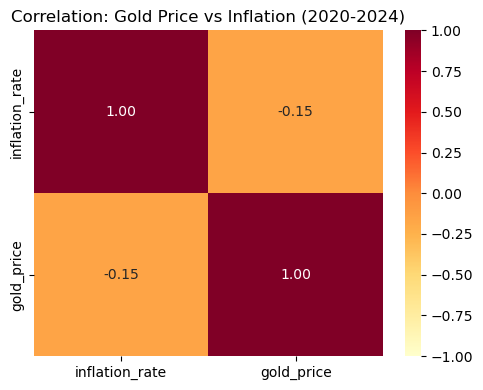

In [34]:
import seaborn as sns

corr_gold = merged[["inflation_rate", "gold_price"]].corr()
display(corr_gold)

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_gold,
    annot=True,
    cmap="YlOrRd",
    vmin=-1, vmax=1,
    fmt=".2f"
)
plt.title("Correlation: Gold Price vs Inflation (2020-2024)")
plt.tight_layout()
plt.show()

The data shows that the correlation between inflation and gold price is negative, and negative correlation means that when inflation rise, gold prices tended to decrease slightly, so gold is not a good hedge against hedge fund.

### 6) Conclusion
Based on the analysis of the 2020–2024 period, the results indicate that oil price is a more significant driver of the inflation rate compared to global supply chain pressures. While supply chain disruptions contributed to initial volatility, but after looking at the correlation, it shows that oil price had a more direct impact on the inflation during this cycle. Moreover, the study about gold prices points out that it is not a an effective hedge. These results highlight the economic dynamics of the post pandemic era, where energy dependency remained a primary factor in driving price instability.

###  Statement of AI Use
AI tools (Chat GPT, Claude) were used mainly to debug errors in some parts, and provided the explanations for codes to ensure my understanding.